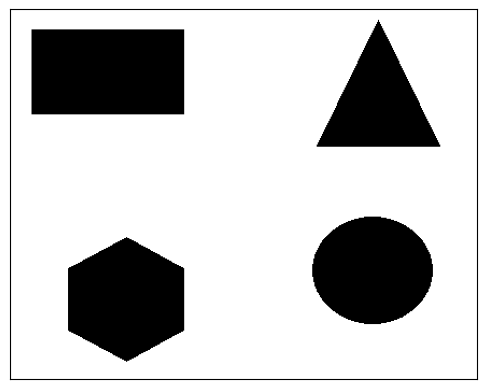

In [12]:
import cv2
import numpy as np
import imutils
from matplotlib import pyplot as plt
img = cv2.imread('ShapeColor.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, threshold = cv2.threshold(gray, 250, 255, cv2.THRESH_BINARY)
plt.imshow(threshold,cmap=plt.cm.gray), plt.xticks([]), plt.yticks([])
plt.show()

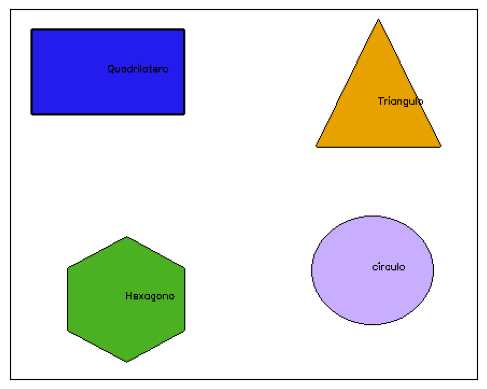

In [13]:


contours, _ = cv2.findContours(threshold, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

i = 0
for contour in contours:

    if i == 0:
        i = 1
        continue

    approx = cv2.approxPolyDP(contour, 0.01 * cv2.arcLength(contour, True), True)

    cv2.drawContours(img, [contour], 0, (0, 0, 0), 1)

    M = cv2.moments(contour) # Cálculo dos momentos
    if M['m00'] != 0.0: #Verificando se a massa é diferente de zero
    # Cálculo do centróide
        x = int(M['m10']/M['m00'])
        y = int(M['m01']/M['m00'])

    if len(approx) == 3:
        cv2.putText(img, 'Triangulo', (x, y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0, 0, 0), 1)

    elif len(approx) == 4:
        cv2.putText(img, 'Quadrilatero', (x, y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0, 0, 0), 1)

    elif len(approx) == 5:
        cv2.putText(img, 'Pentagono', (x, y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0, 0, 0), 1)

    elif len(approx) == 6:
        cv2.putText(img, 'Hexagono', (x, y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0, 0, 0), 1)

    else:
        cv2.putText(img, 'circulo', (x, y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0, 0, 0), 1)

#final=cv2.drawContours(img, [contour], 0, (0, 0, 255), 2)

plt.imshow(img), plt.xticks([]), plt.yticks([])
plt.show()

#cv2.imshow('shapes', img)
#cv2.waitKey(0)
#cv2.destroyAllWindows()